# N1 · Explore the WRF output and extract 3-D subsets

This notebook does one job: turn raw WRF postprocessed output into the
`data/3D_subsets_*/subset_*.npz` files that every other notebook and the whole
assimilation pipeline consume.

The extraction logic itself lives in **`src/extract_3d_subset.py`**, so the same
job also runs headless:

```bash
python src/extract_3d_subset.py --config configs/build_3D_section_post_SINGLECONF.yaml
```

What the notebook adds is the part that is genuinely interactive: looking at the
domain, choosing the sub-box, and checking the result.

| Source format | Reader | Used for |
|---|---|---|
| `post` | plain `netCDF4` | all the 2024 PREVENIR data |
| `wrfout` | `wrf-python` | legacy raw WRF files |

**Steps.** 1 · inspect a source file → 2 · look at the domain → 3 · box to grid
indices → 4 · the config → 5 · run → 6 · verify → 7 · health-sweep everything.

In [1]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import netCDF4

import nbcommon as nb
nb.banner()

# ── configuration: the only cell with paths in it ──────────────────────────
FORMAT      = "post"

# Any single member file, used to inspect the domain and snap the box corners.
SAMPLE_FILE = ("/home/jruiz/datosdemerzel/"
               "PREVENIR_LOWRESOLUTION_DA_FUGAKU_2024031900_5MIN_WINIT_SINGLECONF/"
               "POST/GUES/20240319180000/WRF.D20240319180000.T3D.M001.nc")

CONFIG_YAML = str(nb.REPO / "configs" / "build_3D_section_post_SINGLECONF.yaml")

# Safety latch. Extraction reads 60 members and writes 1.3-6.8 GB; flip to True
# only when you actually mean to (re)write the npz.
RUN_EXTRACTION = False

print("sample file exists:", os.path.isfile(SAMPLE_FILE))
print("config exists     :", os.path.isfile(CONFIG_YAML))

SIGN CONVENTION -- one rule, enforced by this module.

  Every quantity named `skill` is  prior - analysis.
  POSITIVE MEANS THE ANALYSIS IS BETTER THAN THE PRIOR.

  There is no other difference in this module. nbcommon exports no `drmse`, no
  `delta`, no `d_*`. skill() is the only function that subtracts a prior from an
  analysis, and it always subtracts in that order.

  `spread` is NOT a skill metric -- lower spread is not better -- and
  skill(metric='spread') raises.

  `bias`, `skew` and `kurt` are compared as magnitudes: skill = |prior| - |analysis|.
  (skew/kurt at the _w_/_u_ reductions are already stored as means of |.|, so the
  magnitude is not taken twice; see da/metrics.py.)

  Colour: CMAP_SKILL is blue at positive (better), red at negative (worse), always
  centred on 0. It is used with skill() output and nothing else.

  Column names are NATIVE and the variable suffix is LAST:
      crps_f_w_w   = loc-weighted CRPS of vertical wind
      rmse_f_u_u   = unweighted   

## 1 · What is in a source file

The postprocessed files are CF-convention netCDF with a single time step and a
`(XTIME, level_z, y, x)` layout. The extractor needs nine variables; the assert
below fails loudly rather than producing a subset full of NaN.

**Unit trap.** In these files hydrometeors are **g/kg** and pressure is **hPa**.
`extract_3d_subset._get_vars_post` converts them to kg/kg and Pa on the way into
the npz. Anything reading the raw file directly — including the next figure —
has to apply the same conversion, or the reflectivity operator sees a mixing
ratio 1000× too large.

In [2]:
NEEDED = ["XLAT", "XLONG", "level_z", "QGRAUP", "QRAIN", "QSNOW",
          "T", "PRESSURE", "Umet", "Vmet", "W"]

with netCDF4.Dataset(SAMPLE_FILE) as nc:
    print("dimensions:", {k: len(v) for k, v in nc.dimensions.items()})
    missing = [v for v in NEEDED if v not in nc.variables]
    assert not missing, f"source file is missing {missing}"

    print(f"\n{'variable':<10} {'shape':<22} {'units':<10} range")
    for v in NEEDED:
        var = nc.variables[v]
        u = getattr(var, "units", "-")
        a = np.ma.filled(var[:].astype("f8"), np.nan)
        print(f"{v:<10} {str(var.shape):<22} {u:<10} "
              f"[{np.nanmin(a):.4g}, {np.nanmax(a):.4g}]")

    LEVEL_Z = nc.variables["level_z"][:].astype(float)
    XLAT    = nc.variables["XLAT"][:]
    XLONG   = nc.variables["XLONG"][:]

print(f"\nvertical levels [m]: {LEVEL_Z}")
print(f"domain: lat [{XLAT.min():.2f}, {XLAT.max():.2f}]  "
      f"lon [{XLONG.min():.2f}, {XLONG.max():.2f}]")

dimensions: {'y': 899, 'x': 559, 'XTIME': 1, 'level_z': 12}

variable   shape                  units      range
XLAT       (899, 559)             degrees_north [-49.43, -17.08]
XLONG      (899, 559)             degrees_east [-76.7, -47.3]
level_z    (12,)                  m          [250, 1.4e+04]
QGRAUP     (1, 12, 899, 559)      g kg-1     [-1.314e-21, 7.107]


<ipython-input-1-559620d1f13f>:12: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  u = getattr(var, "units", "-")
<ipython-input-1-559620d1f13f>:13: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  a = np.ma.filled(var[:].astype("f8"), np.nan)


QRAIN      (1, 12, 899, 559)      g kg-1     [-7.771e-18, 9.479]
QSNOW      (1, 12, 899, 559)      g kg-1     [-1.944e-21, 5.096]
T          (1, 12, 899, 559)      K          [183.6, 310.4]
PRESSURE   (1, 12, 899, 559)      hPa        [55.77, 986.5]
Umet       (1, 12, 899, 559)      m s-1      [-22.52, 77.06]
Vmet       (1, 12, 899, 559)      m s-1      [-37.92, 28.39]
W          (1, 12, 899, 559)      m s-1      [-8.855, 30.38]

vertical levels [m]: [  250.   500.  1000.  2000.  3000.  4000.  5000.  6000.  8000. 10000.
 12000. 14000.]
domain: lat [-49.43, -17.08]  lon [-76.70, -47.30]


<ipython-input-1-559620d1f13f>:17: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  LEVEL_Z = nc.variables["level_z"][:].astype(float)
<ipython-input-1-559620d1f13f>:18: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  XLAT    = nc.variables["XLAT"][:]
<ipython-input-1-559620d1f13f>:19: DeprecationWarning: `np.bool` is a deprecated alias for the builtin 

## 2 · The domain and the storm

The box is a trade-off. Everything downstream scales with it: the npz is
`nx · ny · nz · 60 · 8 · 4` bytes uncompressed, and the multi-obs assimilation
allocates several arrays of that size at once. The full low-resolution domain at
all 60 members is about 10 GB; the SINGLECONF box below is about 2.9 GB.

The map is a **column-maximum reflectivity** of one member, which is the field
that actually shows where the observations will be.

<ipython-input-1-ab7fb392004f>:4: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  g = lambda v, s=1.0: np.ma.filled(nc.variables[v][0].astype("f8"), np.nan) * s


column-max dBZ: [0.0, 65.7]


/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,


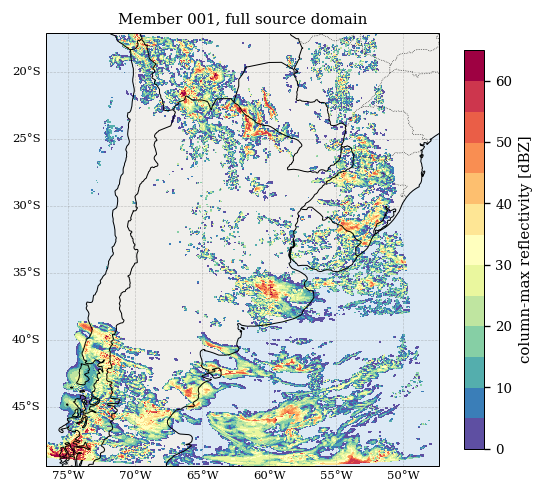

In [3]:
# Read the hydrometeors and thermodynamics, applying the SAME unit conversions
# the extractor applies (g/kg -> kg/kg, hPa -> Pa).
with netCDF4.Dataset(SAMPLE_FILE) as nc:
    g = lambda v, s=1.0: np.ma.filled(nc.variables[v][0].astype("f8"), np.nan) * s
    qg, qr, qs = g("QGRAUP", 1e-3), g("QRAIN", 1e-3), g("QSNOW", 1e-3)
    tk, pa     = g("T"), g("PRESSURE", 100.0)

# Vectorised over the whole (nz, ny, nx) field -- one call, not a triple loop.
dbz3d   = nb.calc_ref_np(qr, qs, qg, tk, pa, min_dbz=0.0)
dbz_max = np.nanmax(dbz3d, axis=0)                      # (ny, nx)
print("column-max dBZ:", f"[{np.nanmin(dbz_max):.1f}, {np.nanmax(dbz_max):.1f}]")

import cartopy.crs as ccrs
fig, ax = plt.subplots(figsize=(nb.COL_W * 1.6, nb.COL_W * 1.9),
                       subplot_kw=dict(projection=ccrs.PlateCarree()))
nb.setup_map(ax, extent=(XLONG.min(), XLONG.max(), XLAT.min(), XLAT.max()))
pm = ax.pcolormesh(XLONG, XLAT, np.where(dbz_max > 0, dbz_max, np.nan),
                   cmap=nb.DBZ_CMAP, norm=nb.DBZ_NORM,
                   shading="auto", transform=ccrs.PlateCarree())
fig.colorbar(pm, ax=ax, shrink=0.7, label="column-max reflectivity [dBZ]")
ax.set_title("Member 001, full source domain")
plt.show()

### Choose the box

Run the next cell and drag a rectangle over the storm. It needs an interactive
backend (`%matplotlib widget`); if that is unavailable the literal `BBOX`
fallback keeps the notebook running top to bottom, which is what a headless
re-execution needs.

<ipython-input-1-a246dd895b51>:9: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  axs.pcolormesh(XLONG, XLAT, np.where(dbz_max > 0, dbz_max, np.nan),


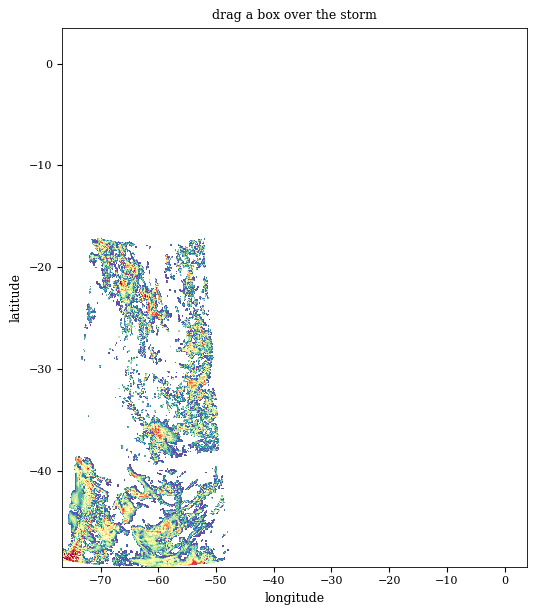

BBOX = {'lat': (-41.0, -25.5), 'lon': (-68.5, -55.5)}


In [4]:
# Fallback = the box the shipped SINGLECONF config already uses.
BBOX = dict(lat=(-41.0, -25.5), lon=(-68.5, -55.5))

try:
    get_ipython().run_line_magic("matplotlib", "widget")
    from matplotlib.widgets import RectangleSelector

    figs, axs = plt.subplots(figsize=(6, 7))
    axs.pcolormesh(XLONG, XLAT, np.where(dbz_max > 0, dbz_max, np.nan),
                   cmap=nb.DBZ_CMAP, norm=nb.DBZ_NORM, shading="auto")
    axs.set_xlabel("longitude"); axs.set_ylabel("latitude")
    axs.set_title("drag a box over the storm")

    def _on_select(epress, erelease):
        BBOX["lon"] = (epress.xdata, erelease.xdata)
        BBOX["lat"] = (epress.ydata, erelease.ydata)
        print(f"BBOX = {BBOX}")

    _sel = RectangleSelector(axs, _on_select, useblit=True, interactive=True)
    plt.show()
except Exception as e:
    print(f"interactive selector unavailable ({type(e).__name__}); using the literal BBOX")

print("BBOX =", BBOX)

## 3 · Box → grid indices

One ordering trap, stated once: **`XLAT`/`XLONG` are `(y, x)` = `(j, i)`**, and
`ll_to_ij_post` returns `(j, i)` in that order — but the config keys are
`i_start/i_end` (west–east) and `j_start/j_end` (south–north), and the npz
`state_ensemble` is `(nx, ny, nz, Ne, 8)`. So the array axes are transposed
relative to the coordinate arrays for the whole rest of the pipeline.
`nbcommon.map_field` hides this everywhere else; here it is explicit because the
config wants it explicit.

In [5]:
from extract_3d_subset import ll_to_ij_post

(j0, i0) = ll_to_ij_post(SAMPLE_FILE, min(BBOX["lat"]), min(BBOX["lon"]))
(j1, i1) = ll_to_ij_post(SAMPLE_FILE, max(BBOX["lat"]), max(BBOX["lon"]))
i_start, i_end = sorted((i0, i1))
j_start, j_end = sorted((j0, j1))

nx, ny = i_end - i_start, j_end - j_start
nz     = len(LEVEL_Z) - 1          # k_end: -1 drops the top level
NE, NVAR = 60, 8
gb = nx * ny * nz * NE * NVAR * 4 / 1e9

print("paste into the config's subset_3d block:\n")
print(f"    k_start: 0\n    k_end:   -1")
print(f"    j_start: {j_start}      # south-north")
print(f"    j_end:   {j_end}")
print(f"    i_start: {i_start}      # west-east")
print(f"    i_end:   {i_end}\n")
print(f"snapped box : lat [{XLAT[j_start, i_start]:.3f}, {XLAT[j_end-1, i_end-1]:.3f}]  "
      f"lon [{XLONG[j_start, i_start]:.3f}, {XLONG[j_end-1, i_end-1]:.3f}]")
print(f"subset grid : nx={nx}  ny={ny}  nz={nz}  Ne={NE}")
print(f"npz payload : {gb:.2f} GB uncompressed  "
      f"(multi-obs holds ~3 arrays of this size at once)")

paste into the config's subset_3d block:

    k_start: 0
    k_end:   -1
    j_start: 236      # south-north
    j_end:   667
    i_start: 142      # west-east
    i_end:   444

snapped box : lat [-40.988, -25.534]  lon [-68.477, -55.518]
subset grid : nx=302  ny=431  nz=11  Ne=60
npz payload : 2.75 GB uncompressed  (multi-obs holds ~3 arrays of this size at once)


## 4 · The extraction config

`{init}` is taken **literally from `paths.start`** (it is the DA init directory),
while `{date}` is formatted from each entry of the `init_date … end_date` range —
they are not the same thing. `{member}` is zero-padded to `pad` digits.

Note the hour is not a config parameter: to extract a different valid time you
edit `start` / `init_date` / `end_date` **and** the output directory name.

In [6]:
import yaml
with open(CONFIG_YAML) as f:
    cfg = yaml.safe_load(f)
job = cfg["cross_sections_job"]
print(yaml.dump(job, sort_keys=False, default_flow_style=False))

# Pre-flight: resolve member 001 and stat it. Fails in a second rather than 40 minutes.
p = job["paths"]
probe = (p["pattern"].replace("{init}", p["start"])
                     .replace("{date}", p["init_date"].replace("-", "").replace("_", "")
                              .replace(":", ""))
                     .replace("{member}", "001"))
print("probe path:", probe)
print("exists    :", os.path.isfile(probe))
if not os.path.isfile(probe):
    cand = sorted(glob.glob(p["pattern"].replace("{init}", p["start"])
                            .replace("{date}", "*").replace("{member}", "001")))
    print(f"member-001 files actually present for this init: {len(cand)}")
    for c in cand[:5]:
        print("   ", os.path.basename(c))

format: post
paths:
  pattern: /home/jruiz/datosdemerzel/PREVENIR_LOWRESOLUTION_DA_FUGAKU_2024031900_5MIN_WINIT_SINGLECONF/POST/GUES/{init}/WRF.D{date}.T3D.M{member}.nc
  output: /home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/3D_subsets_20240319_GUES_SINGLECONF_20240320060000/subset_{date}.npz
  date_fmt: '%Y%m%d%H%M%S'
  start: '20240320060000'
  init_date: 2024-03-20_06:00:00
  end_date: 2024-03-20_06:00:00
  freq: 1H
ensemble:
  mem_ini: 1
  mem_end: 60
  pad: 3
subset_3d:
  k_start: 0
  k_end: -1
  j_start: 222
  j_end: 673
  i_start: 140
  i_end: 447

probe path: /home/jruiz/datosdemerzel/PREVENIR_LOWRESOLUTION_DA_FUGAKU_2024031900_5MIN_WINIT_SINGLECONF/POST/GUES/20240320060000/WRF.D20240320060000.T3D.M001.nc
exists    : True


## 5 · Run the extraction

Set `RUN_EXTRACTION = True` in cell 2 first. This reads all 60 members and writes
one npz per date in the range. Missing member files are filled with NaN and
warned about rather than aborting the run, so **read the warnings**.

In [7]:
if RUN_EXTRACTION:
    from extract_3d_subset import process_data
    process_data(CONFIG_YAML)
else:
    print("RUN_EXTRACTION is False -- skipping.\n"
          "Equivalent CLI:\n"
          f"    python src/extract_3d_subset.py --config {CONFIG_YAML}")

RUN_EXTRACTION is False -- skipping.
Equivalent CLI:
    python src/extract_3d_subset.py --config /nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/configs/build_3D_section_post_SINGLECONF.yaml


## 6 · The output schema

This is the reference the other notebooks cite. Every subset npz holds exactly
five `float32` arrays:

| key | shape | meaning |
|---|---|---|
| `state_ensemble` | `(nx, ny, nz, Ne, 8)` | the prior ensemble |
| `lats` | `(ny, nx)` | latitude, **transposed relative to the state** |
| `lons` | `(ny, nx)` | longitude, same transposition |
| `z_heights` | `(nz, ny, nx)` | height ASL [m] |
| `pos_km` | `(nx, ny, nz, 3)` | `[x east, y north, z]` in km, origin at grid `(0,0)` |

Variable index — the **last** axis of `state_ensemble`, and the order
`nbcommon.VI` encodes:

| idx | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 |
|---|---|---|---|---|---|---|---|---|
| var | `QGRAUP` | `QRAIN` | `QSNOW` | `T` | `P` | `UA` | `VA` | `WA` |
| unit | kg/kg | kg/kg | kg/kg | K | Pa | m/s | m/s | m/s |

Two things that are **not** in the npz and must be derived: **reflectivity**
(`nbcommon.hx`, from `qr/qs/qg/T/P`) and any 2-D field.

`pos_km` is relative to **each subset's own corner**, so `x_km` from a 3.95 km
SINGLECONF grid and a 1.98 km high-resolution grid are not comparable.

In [8]:
OUT_NPZ = job["paths"]["output"].replace(
    "{date}", job["paths"]["init_date"].replace("-", "").replace("_", "").replace(":", ""))
print("verifying", OUT_NPZ, "\n")

if os.path.isfile(OUT_NPZ):
    keys = nb.peek_npz(OUT_NPZ)          # headers only: no decompression
    for k, (shape, dt) in sorted(keys.items()):
        print(f"  {k:<16} {str(shape):<28} {dt}")

    assert set(keys) == set(nb.SUBSET_KEYS), f"unexpected keys: {sorted(keys)}"
    se = keys["state_ensemble"][0]
    assert se[-1] == 8, f"state_ensemble last axis is {se[-1]}, expected 8"
    assert keys["lats"][0] == (se[1], se[0]), "lats is not (ny, nx)"

    geo = nb.load_subset(OUT_NPZ, keys=("pos_km", "z_heights"))
    pk  = geo["pos_km"]
    print(f"\n  dx = {abs(pk[1,0,0,0] - pk[0,0,0,0]):.3f} km   "
          f"dy = {abs(pk[0,1,0,1] - pk[0,0,0,1]):.3f} km")
    print(f"  z levels [km]: {np.round(pk[0,0,:,2], 2)}")
else:
    print("not written yet -- set RUN_EXTRACTION = True and re-run cell 13.")

verifying /home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/3D_subsets_20240319_GUES_SINGLECONF_20240320060000/subset_20240320060000.npz 

  lats             (451, 307)                   float32
  lons             (451, 307)                   float32
  pos_km           (307, 451, 11, 3)            float32
  state_ensemble   (307, 451, 11, 60, 8)        float32
  z_heights        (11, 451, 307)               float32

  dx = 3.951 km   dy = 3.953 km
  z levels [km]: [ 0.25  0.5   1.    2.    3.    4.    5.    6.    8.   10.   12.  ]


## 7 · Visual check

The storm must sit inside the box with room to spare. If it touches an edge the
localization radius will run off the domain and the analysis near that edge is
truncated.

saved N1_extraction_check.pdf / N1_extraction_check.png


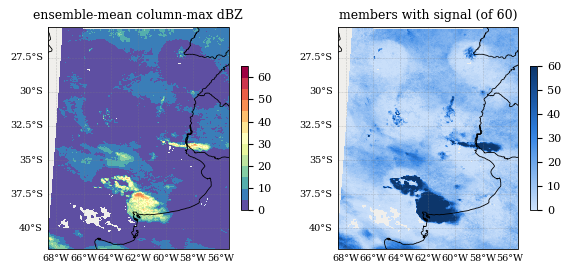

In [9]:
if os.path.isfile(OUT_NPZ):
    st  = nb.prior_stats(OUT_NPZ, min_dbz=0.0)
    geo = nb.load_subset(OUT_NPZ, keys=("lats", "lons"))
    colmax = np.nanmax(st["dbz_mean"], axis=2)          # (nx, ny)

    fig, axes = plt.subplots(1, 2, figsize=(nb.PAGE_W, nb.PAGE_W * 0.42),
                             subplot_kw=dict(projection=ccrs.PlateCarree()))
    for ax, (fld, ttl, kw) in zip(axes, [
            (colmax, "ensemble-mean column-max dBZ",
             dict(cmap=nb.DBZ_CMAP, norm=nb.DBZ_NORM)),
            (np.nanmax(st["n_active"], axis=2), f"members with signal (of {int(st['Ne'])})",
             dict(cmap=nb.CMAP_SEQ, vmin=0, vmax=int(st["Ne"])))]):
        nb.setup_map(ax)
        pm = nb.map_field(ax, geo["lats"], geo["lons"],
                          np.where(fld > 0, fld, np.nan),
                          transform=ccrs.PlateCarree(), **kw)
        fig.colorbar(pm, ax=ax, shrink=0.65)
        ax.set_title(ttl)
    nb.save_fig(fig, "N1_extraction_check")
    plt.show()
else:
    print("nothing to plot yet.")

## 8 · Health sweep of every subset on disk

This is **N2's input gate**: N2 must only ever be pointed at files that pass here.
The sweep reads zip headers only, so it costs nothing even across ~130 GB.

Two failures are already known and expected:

* `..._SINGLECONF_20240319150000` — truncated write, not a readable zip.
* `..._DAFCST_20240319180000` — has `state_ensemble` but no `pos_km`, so
  `run_experiment.py` raises `KeyError` on it.

In [10]:
import pandas as pd

rows = []
for d in sorted(nb.DATA.glob("3D_subsets*")):
    for f in sorted(d.glob("*.npz")):
        status, detail = nb.check_subset(str(f))
        rows.append(dict(directory=d.name, file=f.name, status=status,
                         detail=detail, GB=round(f.stat().st_size / 1e9, 2)))

health = pd.DataFrame(rows)
print(health["status"].value_counts().to_string(), "\n")
bad = health[health.status != "PASS"]
if len(bad):
    print("NOT USABLE:")
    print(bad[["directory", "file", "status", "detail"]].to_string(index=False))
else:
    print("every subset on disk is readable and complete.")

health.to_csv(nb.DERIVED / "N1_subset_health.csv", index=False)
print(f"\nwrote {nb.DERIVED / 'N1_subset_health.csv'}")
health.head(12)

PASS            44
MISSING-KEYS     2
CORRUPT          1 

NOT USABLE:
                                         directory                                         file       status                     detail
                                        3D_subsets ensemble_3D_sections_2023-12-16_19:00:00.npz MISSING-KEYS             missing pos_km
         3D_subsets_20240319_DAFCST_20240319180000                    subset_20240319180000.npz MISSING-KEYS missing lats, lons, pos_km
3D_subsets_20240319_GUES_SINGLECONF_20240319150000                    subset_20240319150000.npz      CORRUPT     File is not a zip file

wrote /nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N1_subset_health.csv


,directory,file,status,detail,GB
0,3D_subsets,ensemble_3D_sections_2023-12-16_19:00:00.npz,MISSING-KEYS,missing pos_km,0.42
1,3D_subsets_20240319_DAFCST_20240319180000,subset_20240319180000.npz,MISSING-KEYS,"missing lats, lons, pos_km",2.50
2,3D_subsets_20240319_DAFCST_20240319180000,subset_20240320180000.npz,PASS,558x898x11x60x8,6.75
3,3D_subsets_20240319_GUES_20240319180000,subset_20240319180000.npz,PASS,558x898x11x60x8,6.75
4,3D_subsets_20240319_GUES_20240319180000,subset_20240319180500.npz,PASS,558x898x11x60x8,6.83
5,3D_subsets_20240319_GUES_20240319180000,subset_20240319181000.npz,PASS,558x898x11x60x8,6.78
6,3D_subsets_20240319_GUES_20240319180000,subset_20240319181500.npz,PASS,558x898x11x60x8,6.79
7,3D_subsets_20240319_GUES_20240319180000,subset_20240319182000.npz,PASS,558x898x11x60x8,6.77
8,3D_subsets_20240319_GUES_20240319180000,subset_20240319182500.npz,PASS,558x898x11x60x8,6.77
9,3D_subsets_20240319_GUES_20240319180000,subset_20240319183000.npz,PASS,558x898x11x60x8,6.76
